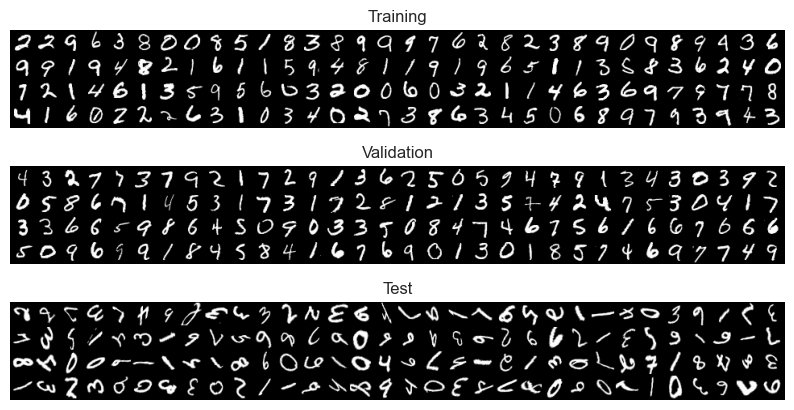

In [1]:
from utils.eval.vis import plt_setup_latex
from utils.transform_sequence import TransformSequence, create_sampler
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist'  # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data", train=True, download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data", train=False, download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = torch.utils.data.random_split(dataset_val_test, [5000, 5000])
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data", train=True, download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data", train=False, download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = torch.utils.data.random_split(dataset_val_test, [5000, 5000])

transformations = [AffineTransformation2D.ROTATION.value, AffineTransformation2D.SHEARING_X.value,
                   AffineTransformation2D.SHEARING_Y.value
    , AffineTransformation2D.SCALING_X.value, AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi, torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1 / 1.3 - 1, 0.3),), ((1 / 1.3 - 1, 0.3),)]
n_samples = 17


transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre, sampler, return_transformation=False, batch_size=batch_size)

train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,
                                           persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,
                                         persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,
                                          persistent_workers=True)
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size // 4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size // 4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size // 4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [2]:
plt.rcParams['figure.dpi'] = 300

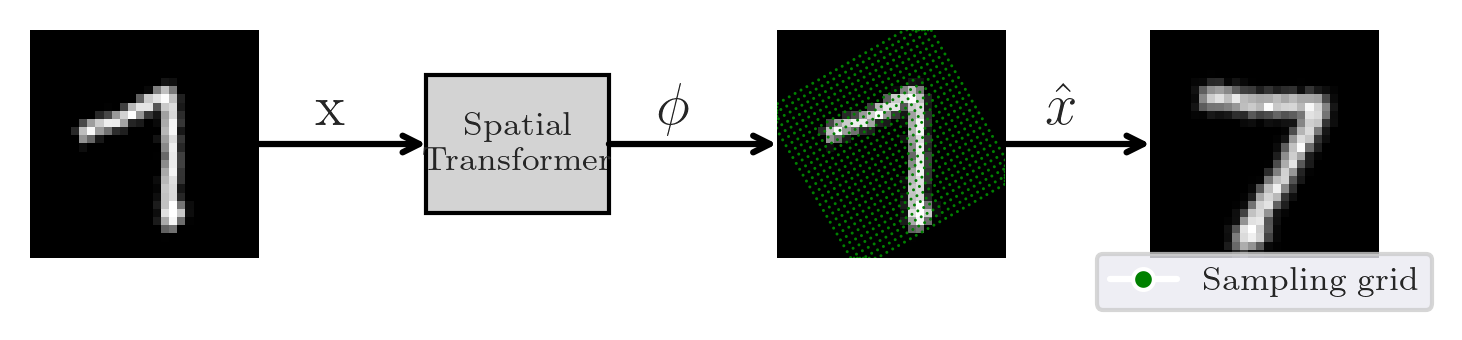

In [3]:
import math
import torch
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow, ConnectionPatch

# Make all fonts smaller
plt.rcParams['font.size'] = 8

# 1) Load an MNIST digit
transform = transforms.Compose([transforms.ToTensor()])
mnist = torchvision.datasets.MNIST(root='./data', train=False,
                                   download=True, transform=transform)
img, _ = mnist[0]               # [1,28,28]
img = img.unsqueeze(0)          # [1,1,28,28]

# 2) Predict θ = rotation (30°) + scale (1.2)
angle = math.radians(30)
scale = 1.2
c, s = math.cos(angle), math.sin(angle)
theta = torch.tensor([[
    [ scale * c, -scale * s, 0.0 ],
    [ scale * s,  scale * c, 0.0 ]
]], dtype=torch.float32)       # [1,2,3]

# 3) Forward sampling → transformed image
grid_fwd    = F.affine_grid(theta, img.size(), align_corners=False)
transformed = F.grid_sample(img, grid_fwd, align_corners=False)

# 4) Invert θ for reconstruction
M = torch.eye(3).unsqueeze(0)       # [1,3,3]
M[0,:2,:2] = theta[0,:2,:2]
M[0,:2, 2] = theta[0,:2, 2]
M_inv       = torch.linalg.inv(M)
theta_inv   = M_inv[:, :2, :]      # [1,2,3]

# 5) Backward sampling → reconstructed
grid_bwd      = F.affine_grid(theta_inv, img.size(), align_corners=False)
reconstructed = F.grid_sample(transformed, grid_bwd, align_corners=False)

# 6) Plot 1×4 panels (reordered: Transformed → ST block → Grid → Reconstructed)

W = plt_setup_latex()

fig, ax = plt.subplots(1, 4, figsize=(W , W/4))

# Panel 1: Transformed (θ applied)
ax[0].imshow(transformed[0,0].detach().numpy(), cmap='gray')
ax[0].axis('off')

# Panel 2: Spatial Transformer block
ax[1].axis('off')
rect = Rectangle((0.1,0.2), 0.8, 0.6,
                 facecolor='lightgray', edgecolor='black',
                 transform=ax[1].transAxes)
ax[1].add_patch(rect)
ax[1].text(
    0.5, 0.5, "Spatial \nTransformer",
    ha='center', va='center',
    fontsize=8, weight='bold',
    transform=ax[1].transAxes
)

# Panel 3: Sampling grid on transformed image
grid_bwd = grid_bwd.clamp(-1, 1)

ax[2].imshow(transformed[0,0].detach().numpy(),
             cmap='gray', extent=(-1,1,1,-1))
ax[2].scatter(grid_bwd[0,...,0].numpy(),
              grid_bwd[0,...,1].numpy(),
              s=0.50, c='green', edgecolors='none')
ax[2].axis('off')

# Panel 4: Reconstructed
ax[3].imshow(reconstructed[0,0].detach().numpy(), cmap='gray')
ax[3].axis('off')

# Arrow: panel 1 → panel 2
con = ConnectionPatch(
    xyA=(1,0.5), coordsA=ax[0].transAxes,
    xyB=(0.1,0.5), coordsB=ax[1].transAxes,
    arrowstyle="->", lw=1.5, color='black', zorder=20
)
fig.add_artist(con)

ax[0].text(
    1.25, 0.65,
    'x',
    transform=ax[0].transAxes,
    ha='left', va='center',
    fontsize=14
)

# Arrow: panel 2 → panel 3
con = ConnectionPatch(
    xyA=(0.9,0.5), coordsA=ax[1].transAxes,
    xyB=(0,0.5), coordsB=ax[2].transAxes,
    arrowstyle="->", lw=1.5, color='black', zorder=20
)
fig.add_artist(con)

ax[2].text(
    2.75, 0.65,
    r'$\phi$',
    transform=ax[0].transAxes,
    ha='left', va='center',
    fontsize=14
)

# Arrow: panel 3 → panel 4
con = ConnectionPatch(
    xyA=(1,0.5), coordsA=ax[2].transAxes,
    xyB=(0,0.5), coordsB=ax[3].transAxes,
    arrowstyle="->", lw=1.5, color='black', zorder=20
)
fig.add_artist(con)

ax[3].text(
    4.45, 0.65,
    r'$\hat{x}$',
    transform=ax[0].transAxes,
    ha='left', va='center',
    fontsize=14
)
#add legend for grid
plt.legend(
    [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5)],
    ['Sampling grid'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.3),
    fontsize=8
)

plt.tight_layout()
plt.savefig("spatial_transformer_diagram.png", bbox_inches='tight', dpi=600)
plt.savefig("spatial_transformer_diagram.pdf", bbox_inches='tight', dpi=600)
plt.show()


In [4]:
random_untransformed = next(iter(train_loader))[0][[5]].to(device)

In [5]:
transform_rotate = AffineTransformation2D.ROTATION.value

In [6]:
param = torch.arange(-torch.pi, torch.pi, 2*torch.pi/16).unsqueeze(1).to(device)  # rotation parameters

In [7]:
param.cpu()

tensor([[-3.1416],
        [-2.7489],
        [-2.3562],
        [-1.9635],
        [-1.5708],
        [-1.1781],
        [-0.7854],
        [-0.3927],
        [ 0.0000],
        [ 0.3927],
        [ 0.7854],
        [ 1.1781],
        [ 1.5708],
        [ 1.9635],
        [ 2.3562],
        [ 2.7489]])

In [8]:
from utils.transforms.apply import grid_resample


In [9]:
ts = transform_rotate(param).to(device)
x_transformed = grid_resample(random_untransformed.repeat(len(param), 1, 1, 1), ts)
#add red border to middle image with param equal to 0
x_transformed = x_transformed.repeat(1, 3, 1, 1)  # repeat the image
x_transformed[int(len(param) / 2), 0, :,0] = 1  # set the red channel to 1
x_transformed[int(len(param) / 2), 1, :, 0] = 0  # set the green channel to 0
x_transformed[int(len(param) / 2), 2, :, 0] = 0  # set the blue channel to 0
#second border
x_transformed[int(len(param) / 2), 0, :, -1] = 1  # set the red channel to 1
x_transformed[int(len(param) / 2), 1, :, -1] = 0  # set the green channel to 0
x_transformed[int(len(param) / 2), 2, :, -1] = 0  # set the blue channel to

x_transformed[int(len(param) / 2), 0, 0, :] = 1  # set the
x_transformed[int(len(param) / 2), 1, 0, :] = 0  # set the green channel to 0
x_transformed[int(len(param) / 2), 2, 0, :] = 0  # set the blue channel to 0


x_transformed[int(len(param) / 2), 0, -1, :] = 1  # set the red channel to 1
x_transformed[int(len(param) / 2), 1, -1, :] = 0  # set the green channel to 0
x_transformed[int(len(param) / 2), 2, -1, :] = 0  # set the blue channel to 0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18310237..1.1772815].


(np.float64(-0.5), np.float64(241.5), np.float64(61.5), np.float64(-0.5))

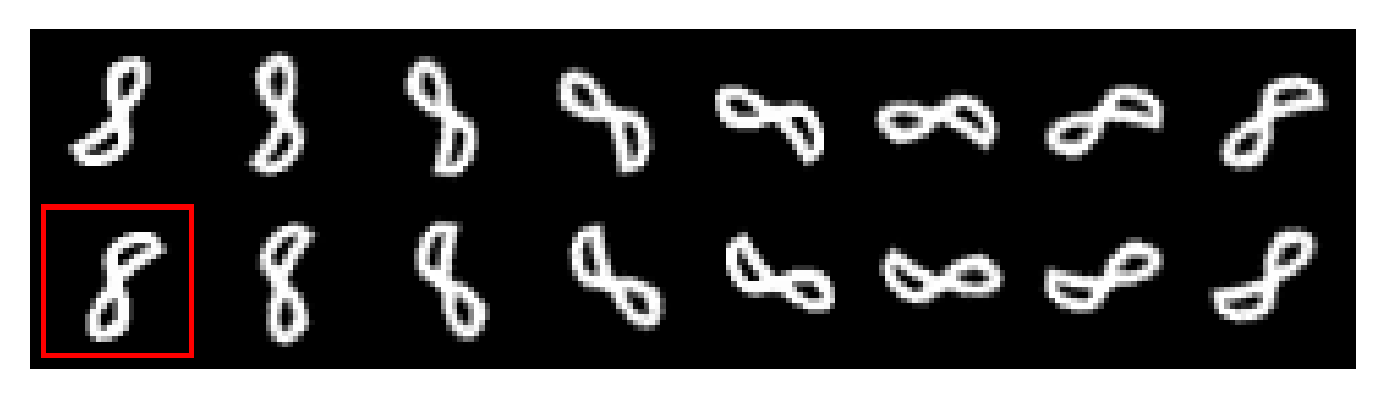

In [10]:
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=8).permute(1, 2, 0).cpu())
#set tight layout()
plt.tight_layout()
#disable axis
plt.axis('off')
#remove white border


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Utility function: rotate a batch of images tensor by 90° k times
def rotate_tensor(x, k):
    """
    Rotate input tensor x (shape [B, C, H, W]) by 90° clockwise k times.
    """
    return torch.rot90(x, k, dims=[-2, -1])

# G-CNN layer for group C4 (rotations by multiples of 90°)
class GConvC4(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(GConvC4, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size

        # Base filter for the identity orientation
        # Shape: [out_channels, in_channels, k, k]
        self.base_weight = nn.Parameter(torch.randn(out_channels, in_channels, kernel_size, kernel_size))
        # Optional bias (shared across group channels)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        """
        x: tensor of shape [B, in_channels, 4, H, W], where dimension 2 indexes orientation in C4.
        Output: tensor of shape [B, out_channels, 4, H', W'], with the same group dimension.
        """
        B, C_in, G, H, W = x.shape
        assert G == 4, "Group size must be 4 for C4."

        # Build the filter bank for each combination of output orientation g and input orientation h.
        # weight[g, h] = rotate(base_weight, 90° * ((g - h) mod 4)).
        # We'll get a tensor of shape [4, out_channels, in_channels, k, k].
        device = x.device
        weights = torch.zeros(
            4, self.out_channels, self.in_channels, self.kernel_size, self.kernel_size,
            device=device
        )

        for g in range(4):
            for h in range(4):
                # angle index = (g - h) mod 4
                angle = (g - h) % 4
                rotated_filter = rotate_tensor(self.base_weight, angle)
                weights[g, :, :, :, :] += rotated_filter

        # Now convolve for each output orientation g
        outputs = []
        for g in range(4):
            conv_sum = 0
            for h in range(4):
                # Convolve x[:,:,h] with weights[g]
                conv_sum = conv_sum + F.conv2d(
                    x[:, :, h, :, :],
                    weights[g],
                    bias=self.bias,
                    padding=self.kernel_size // 2
                )
            # conv_sum shape [B, out_channels, H, W]
            outputs.append(conv_sum.unsqueeze(2))  # -> [B, out_channels, 1, H, W]

        # Concatenate along group dimension -> [B, out_channels, 4, H, W]
        output = torch.cat(outputs, dim=2)
        return output

# Function to "lift" a standard image into a group representation
def lift_to_C4(x):
    """
    x: [B, C, H, W]
    Returns: [B, C, 4, H, W], where dimension 2 holds the 4 rotated versions of x.
    """
    B, C, H, W = x.shape
    xs = []
    for k in range(4):
        xs.append(rotate_tensor(x, k).unsqueeze(2))  # [B, C, 1, H, W]
    return torch.cat(xs, dim=2)  # [B, C, 4, H, W]

# Simple network: Lift -> GConvC4 -> Group Pooling -> FC
class SimpleGCNN(nn.Module):
    def __init__(self):
        super(SimpleGCNN, self).__init__()
        self.gconv = GConvC4(in_channels=1, out_channels=1, kernel_size=3)
        # After group conv and pooling, flatten to a single logit vector for 2 classes
        # Assume input is 28×28 → output of gconv is still 28×28 (due to padding=1)
        self.fc = nn.Linear(1 * 1 * 28 * 28, 2)  # 2 output classes

    def forward(self, x):
        # x: [B, 1, 28, 28]

        # 1) Lift input to group representation
        x_lifted = lift_to_C4(x)  # [B, 1, 4, 28, 28]

        # 2) G-Convolution → [B, 1, 4, 28, 28]
        x_gconv = self.gconv(x_lifted)

        # 3) Group pooling (max over the 4 orientations) → [B, 1, 28, 28]
        x_group_pooled, _ = torch.max(x_gconv, dim=2)

        # 4) Flatten and FC → [B, 2]
        x_flat = x_group_pooled.view(x_group_pooled.size(0), -1)
        logits = self.fc(x_flat)
        return logits, x_gconv

# ---------------------------------------------------
# Demonstration of equivariance and invariance:
# ---------------------------------------------------

# 1) Create the network instance
net = SimpleGCNN()

# 2) Generate a random example image (batch size 1, 1 channel, 28×28)
torch.manual_seed(0)
x = torch.randn(1, 1, 28, 28)

# 3) Create a 90° rotated version of x
x_rot = rotate_tensor(x, 1)

# 4) Forward both through the network
logits_x, feat_x = net(x)
logits_xrot, feat_xrot = net(x_rot)

# === Check equivariance at the feature‐level ===
# feat_x:     [1, 1, 4, 28, 28]
# feat_xrot:  [1, 1, 4, 28, 28]
print("Feature maps for original input: shape", feat_x.shape)
print("Feature maps for rotated input:  shape", feat_xrot.shape)

# For each orientation g ∈ {0,1,2,3}, we expect:
#   feat_xrot[:, :, g] ≈ rotate_tensor(feat_x[:, :, (g - 1) mod 4], 1)
for g in range(4):
    ref = rotate_tensor(feat_x[:, :, (g - 1) % 4, :, :], 1)
    diff = torch.norm(feat_xrot[:, :, g, :, :] - ref).item()
    print(f"Orientation channel {g}: ‖feat_xrot - rotated(feat_x)‖ = {diff:.6f}")

# === Check invariance after group pooling + FC ===
print("\nLogits for original input: ", logits_x.detach().numpy())
print("Logits for rotated input:  ", logits_xrot.detach().numpy())

# Both logits should be (nearly) identical after group pooling, showing invariance.


Feature maps for original input: shape torch.Size([1, 1, 4, 28, 28])
Feature maps for rotated input:  shape torch.Size([1, 1, 4, 28, 28])
Orientation channel 0: ‖feat_xrot - rotated(feat_x)‖ = 0.000022
Orientation channel 1: ‖feat_xrot - rotated(feat_x)‖ = 0.000022
Orientation channel 2: ‖feat_xrot - rotated(feat_x)‖ = 0.000022
Orientation channel 3: ‖feat_xrot - rotated(feat_x)‖ = 0.000023

Logits for original input:  [[3.3730829 2.9803178]]
Logits for rotated input:   [[3.3730829 2.9803169]]


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from e2cnn import gspaces
from e2cnn import nn as enn


class GCNNDownsampled(nn.Module):
    def __init__(self):
        super(GCNNDownsampled, self).__init__()

        # 1) Define the C4 rotation group action
        self.r2_act = gspaces.Rot2dOnR2(N=4)

        # 2) Input field: trivial repr (grayscale)
        self.in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # 3) First equivariant conv: trivial → 8 × regular
        #    We’ll use stride=2 here to downsample 28×28 → 14×14
        out_type1 = enn.FieldType(self.r2_act, 8 * [self.r2_act.regular_repr])
        self.conv1 = enn.R2Conv(
            self.in_type,
            out_type1,
            kernel_size=3,
            stride=3,       # downsample by 2 spatially
            padding=0,
            bias=True
        )
        self.relu1 = enn.ReLU(out_type1, inplace=True)

        # 4) Equivariant pooling layer (optional):
        #    We could further downsample 14×14 → 7×7 by a pointwise max pool.
        #    This is still equivariant, because it pools independently in each orientation slice.
        self.pool1 = enn.PointwiseMaxPool(out_type1, kernel_size=2, stride=1)

        # 5) Second equivariant conv: 8×regular → 16×regular
        #    Input is now 7×7, we’ll keep stride=1 to remain at 7×7
        out_type2 = enn.FieldType(self.r2_act, 16 * [self.r2_act.regular_repr])
        self.conv2 = enn.R2Conv(
            out_type1,
            out_type2,
            kernel_size=4,
            padding=0,
            bias=True
        )
        self.relu2 = enn.ReLU(out_type2, inplace=True)

        # 6) Third equivariant downsampling conv: 16×regular → 32×regular
        #    Stride=2 to go 7×7 → 4×4 (since padding=1, kernel=3, a 7→4 is approximate)
        out_type3 = enn.FieldType(self.r2_act, 32 * [self.r2_act.regular_repr])
        self.conv3 = enn.R2Conv(
            out_type2,
            out_type3,
            kernel_size=3,
            stride=2,      # downsample
            padding=1,
            bias=True
        )
        self.relu3 = enn.ReLU(out_type3, inplace=True)

        # 7) Final group pooling: collapse the 32×regular repr → 32×trivial repr
        self.gpool = enn.GroupPooling(out_type3)

        # 8) After pooling, feature‐map is [B, 32, 4, 4]. We global‐pool over 4×4 → [B, 32]
        self.fc = nn.Linear(32, 2)  # final 2‐class output

    def forward(self, x_geom: enn.GeometricTensor):
        # x_geom: [B,1,28,28] with trivial repr

        # 1) Conv1 (stride=2) → [B, 8×regular, 14, 14]
        x = self.conv1(x_geom)
        x = self.relu1(x)

        # 2) Optional equivariant max‐pool → [B, 8×regular, 7, 7]
        x = self.pool1(x)

        # 3) Conv2 (stride=1) → [B, 16×regular, 7, 7]
        x = self.conv2(x)
        x = self.relu2(x)

        # 4) Conv3 (stride=2) → [B, 32×regular, 4, 4]
        x = self.conv3(x)
        x = self.relu3(x)

        # 5) Group pooling → [B, 32×trivial, 4, 4]
        x = self.gpool(x)

        # 6) Now x.tensor is [B, 32, 4, 4]. Do global spatial mean over 4×4 → [B, 32]
        feat = x.tensor
        spatial_pooled = feat.mean(dim=[2, 3])

        # 7) Final linear → [B, 2]
        logits = self.fc(spatial_pooled)
        return logits


# ---------------------------
# Quick invariance check:
# ---------------------------

model = GCNNDownsampled()

# Random 28×28 image
torch.manual_seed(0)
x = torch.randn(1, 1, 28, 28)

# Wrap as GeometricTensor
x_geom = enn.GeometricTensor(x, model.in_type)

# 1) Forward original
logits_orig = model(x_geom)

# 2) Rotate raw tensor by 90° and wrap again
x_rot = torch.rot90(x, k=1, dims=[-2, -1])
x_rot_geom = enn.GeometricTensor(x_rot, model.in_type)

# 3) Forward rotated
logits_rot = model(x_rot_geom)

print("Logits (orig):", logits_orig.detach().numpy())
print("Logits (rot): ", logits_rot.detach().numpy())


Logits (orig): [[ 0.7519 -0.3177]]
Logits (rot):  [[ 0.7351 -0.3503]]


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\e2cnn\nn\modules\r2_conv\basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/IndexingUtils.h:30.)
  full_mask[mask] = norms.to(torch.uint8)


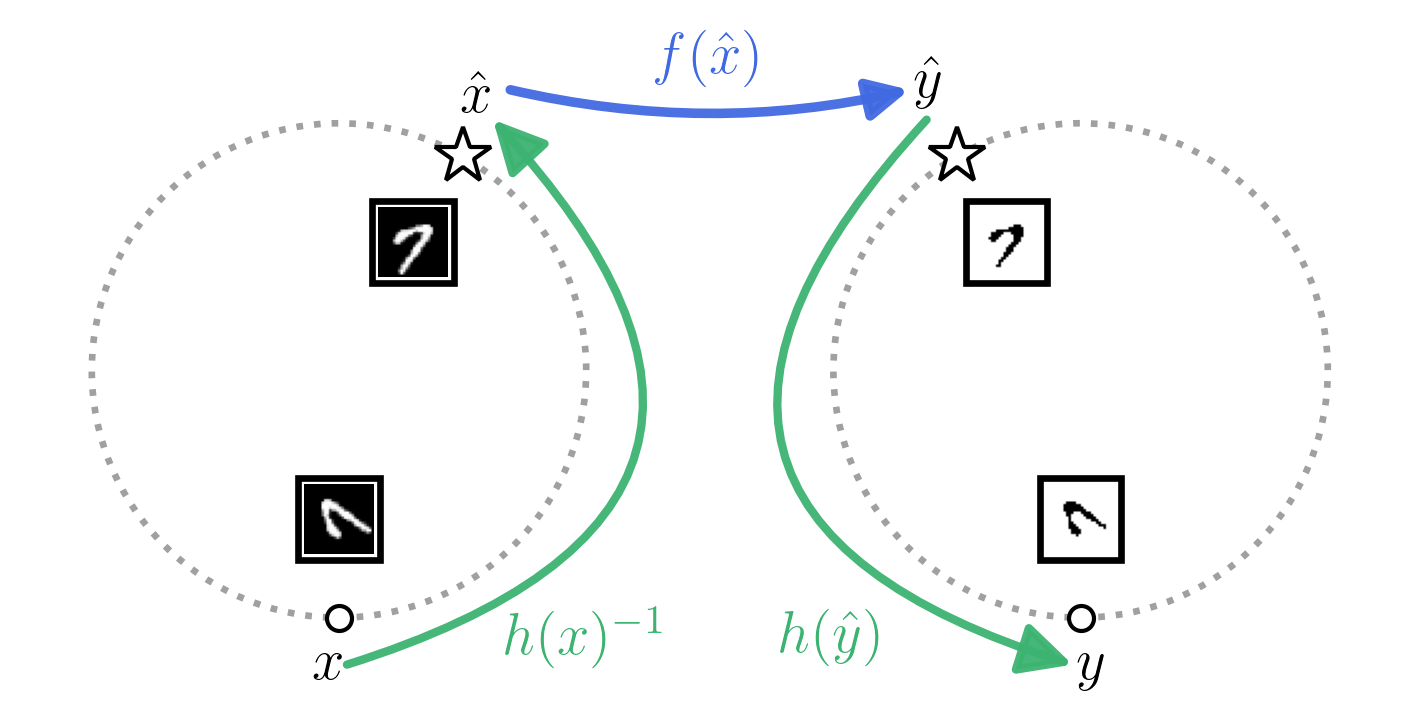

In [70]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from scipy.ndimage import rotate, gaussian_filter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Circle, FancyArrowPatch

def get_mnist_digit(digit=7):
    mnist_data = torchvision.datasets.MNIST(root='./', download=True)
    for img, label in mnist_data:
        if label == digit:
            return np.array(img)
    raise ValueError(f"Digit {digit} not found.")

def place_image(ax, img, center_xy, zoom=0.55, zorder=3):
    im = OffsetImage(img, cmap='gray', zoom=zoom)
    ab = AnnotationBbox(im, center_xy, frameon=True, pad=0.12,
                        bboxprops=dict(edgecolor='black', linewidth=1.6, facecolor='none'),
                        zorder=zorder)
    ax.add_artist(ab)

def _outside_point(pt, center, extra):
    v = np.array(pt) - np.array(center)
    norm = np.linalg.norm(v)
    if norm == 0:
        return np.array(pt)
    return np.array(pt) + (v/norm)*extra

def main():
    original_digit = get_mnist_digit(7)
    x_hat_img = original_digit.copy()
    x_img = rotate(original_digit, 90, reshape=False, cval=0)

    y_hat_img = 255 - original_digit
    y_hat_img = gaussian_filter(y_hat_img, sigma=1.6)
    y_hat_img = (y_hat_img > 127).astype(np.uint8) * 255
    y_img = rotate(y_hat_img, 90, reshape=False, cval=255)

    fig, ax = plt.subplots(figsize=(W, W/2))
    ax.set_aspect('equal')
    ax.axis('off')
    fig.patch.set_facecolor("white")

    left_center = np.array([-1.5, 0.0])
    right_center = np.array([+1.5, 0.0])
    radius = 1.0

    deg = lambda d: d*np.pi/180
    angle_x = deg(-90)
    angle_xhat = deg(60)
    angle_yhat = deg(120)
    angle_y = deg(-90)

    # ---- points ON the circle ----
    x_on_circle = left_center + radius*np.array([np.cos(angle_x), np.sin(angle_x)])
    xhat_on_circle = left_center + radius*np.array([np.cos(angle_xhat), np.sin(angle_xhat)])
    yhat_on_circle = right_center + radius*np.array([np.cos(angle_yhat), np.sin(angle_yhat)])
    y_on_circle = right_center + radius*np.array([np.cos(angle_y), np.sin(angle_y)])

    inward = 0.6
    inside = lambda c, p: c + inward*(p-c)

    x_im_center = inside(left_center, x_on_circle)
    xhat_im_center = inside(left_center, xhat_on_circle)
    yhat_im_center = inside(right_center, yhat_on_circle)
    y_im_center = inside(right_center, y_on_circle)

    # ---- outside LABEL points only ----
    label_out = 0.32
    xhat_label_pt = _outside_point(xhat_on_circle, left_center, label_out)
    yhat_label_pt = _outside_point(yhat_on_circle, right_center, label_out)

    # ---- MNIST images ----
    place_image(ax, x_img,      x_im_center,     zoom=0.60)
    place_image(ax, x_hat_img,  xhat_im_center,  zoom=0.60)
    place_image(ax, y_hat_img,  yhat_im_center,  zoom=0.60)
    place_image(ax, y_img,      y_im_center,     zoom=0.60)

    # ---- circles ----
    ax.add_patch(Circle(left_center, radius, fill=False, linestyle=':',
                        edgecolor='gray', lw=1.6, alpha=0.75))
    ax.add_patch(Circle(right_center, radius, fill=False, linestyle=':',
                        edgecolor='gray', lw=1.6, alpha=0.75))

    # ---- markers ON THE CIRCLE ----
    ax.plot(x_on_circle[0], x_on_circle[1], 'o',
            color='white', markersize=6, zorder=20, markeredgecolor='black')

    ax.plot(y_on_circle[0], y_on_circle[1], 'o',
            color='white', markersize=6, zorder=20, markeredgecolor='black')

    ax.plot(xhat_on_circle[0], xhat_on_circle[1], '*',
            color='white', markersize=14, zorder=20, markeredgecolor='black')

    ax.plot(yhat_on_circle[0], yhat_on_circle[1], '*',
            color='white', markersize=14, zorder=20, markeredgecolor='black')

    # ---- BLUE ARROW from outside label points ----
    blue_rad = 0.12
    f_arrow = FancyArrowPatch(
        posA=xhat_label_pt, posB=yhat_label_pt,
        connectionstyle=f'arc3,rad={blue_rad}',
        arrowstyle='-|>', mutation_scale=20,
        color='royalblue', lw=2.3, alpha=0.95
    )
    ax.add_patch(f_arrow)

    mid = (xhat_label_pt + yhat_label_pt)/2 + np.array([0.0, 0.0])
    ax.text(mid[0], mid[1], r'$f(\hat{x})$', fontsize=14, color='royalblue',
            ha='center', va='bottom')

    # ---- GREEN ARROWS outside ----
    extra = 0.2
    a_left = _outside_point(x_on_circle, left_center, extra)
    b_left = _outside_point(xhat_on_circle, left_center, extra)

    a_right = _outside_point(y_on_circle, right_center, extra)
    b_right = _outside_point(yhat_on_circle, right_center, extra)

    ax.add_patch(FancyArrowPatch(
        posA=a_left, posB=b_left,
        connectionstyle='arc3,rad=0.8',
        arrowstyle='-|>', mutation_scale=26,
        color='mediumseagreen', lw=2.0, alpha=0.95
    ))

    ax.add_patch(FancyArrowPatch(
        posA=b_right, posB=a_right,
        connectionstyle='arc3,rad=0.8',
        arrowstyle='-|>', mutation_scale=26,
        color='mediumseagreen', lw=2.0, alpha=0.95
    ))

    mid_left = (a_left + b_left) / 2
    mid_right = (a_right + b_right) / 2

    ax.text(mid_left[0]+0.7, mid_left[1] -1.0, r'$h(x)^{-1}$',
            fontsize=14, color='mediumseagreen', ha='center', va='center')

    ax.text(mid_right[0]-0.7, mid_right[1] -1.0, r'$h(\hat{y})$',
            fontsize=14, color='mediumseagreen', ha='center', va='center')

    # ---- labels AT OUTSIDE POINTS ----
    ax.text(xhat_label_pt[0]-0.1, xhat_label_pt[1]-0.1,
            r'$\hat{x}$', fontsize=14, ha='center', color='black')

    ax.text(yhat_label_pt[0]+0.05, yhat_label_pt[1]-0.04,
            r'$\hat{y}$', fontsize=14, ha='center', color='black')

    ax.text(x_on_circle[0]-0.04, x_on_circle[1]-0.25,
            r'$x$', fontsize=14, ha='center', color='black')

    ax.text(y_on_circle[0]+0.04, y_on_circle[1]-0.25,
            r'$y$', fontsize=14, ha='center', color='black')

    plt.tight_layout()
    plt.savefig("equivariance_diagram_final.png", bbox_inches='tight', dpi=200)
    plt.savefig("equivariance_diagram_final.pdf", bbox_inches='tight')
    plt.show()

if __name__ == '__main__':
    main()
